# <img style="float: left; padding-right: 10px; width: 250px" src="https://extension.harvard.edu/wp-content/uploads/sites/8/2020/08/image-10.png"> 
### Data Science Capstone Project
### NASA + Smithsonian Team Blue


## **Spring 2026**<br/>

<hr style="height:2pt">

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, shutil

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import regularizers
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [3]:
from pathlib import Path

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## (a)	Import merged AGB/EO data 


In [4]:
file_path = "C:/Users/svazq/HES/Capstone/Merged_Data/AGB_EO_SENTINEL.csv"   

df = pd.read_csv(file_path)

print(df.head())

      dataset       plot_id  start_date    end_date  latitude_x  longitude_x  \
0  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
1  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
2  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
3  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
4  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   

   diameter  height species  plant_AGB_kg  longitude_y  latitude_y  \
0      26.3    12.0  mangle    630.627596    -88.60437    13.22736   
1      28.6    14.0  mangle    784.223246    -88.60437    13.22736   
2      19.2     4.0  mangle    139.136548    -88.60437    13.22736   
3       6.2     8.0  mangle     14.726733    -88.60437    13.22736   
4       5.2     5.0  mangle      9.321734    -88.60437    13.22736   

                  time    Blue   Green     Red     NIR   SWIR1   SWIR2  \
0  2017-01-12 16:16:21  

In [5]:
print("Shape:", df.shape)
df.head()

Shape: (8774, 24)


,dataset,plot_id,start_date,end_date,latitude_x,longitude_x,diameter,height,species,plant_AGB_kg,longitude_y,latitude_y,time,Blue,Green,Red,NIR,SWIR1,SWIR2,NDVI,MNDWI,NBR,EVI,CLOUD_COVERAGE
0,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,26.3,12.0,mangle,630.627596,-88.60437,13.22736,2017-01-12 16:16:21,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
1,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,28.6,14.0,mangle,784.223246,-88.60437,13.22736,2017-01-12 16:16:21,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
2,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,19.2,4.0,mangle,139.136548,-88.60437,13.22736,2017-01-12 16:16:21,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
3,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,6.2,8.0,mangle,14.726733,-88.60437,13.22736,2017-01-12 16:16:21,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0
4,ElSalvador,El_Jobal_9_6,2017-01-01,2017-12-31,13.22736,-88.60437,5.2,5.0,mangle,9.321734,-88.60437,13.22736,2017-01-12 16:16:21,0.0108,0.0377,0.0198,0.2689,0.0915,0.0338,0.862833,-0.416409,0.776677,0.476582,0.0


Data has tree-level rows with:

- tree variables: diameter, height, species
- EO values at a matched date: Blue, Green, Red, NIR, SWIR1, SWIR2, etc.
- target: plant_AGB_kg

The available EO inputs are spectral summaries matched to field observations rather than raw spatial image patches. Therefore, the current dataset supported tabular and dense neural network approaches, but not a CNN. A CNN would require retrieval of the underlying Sentinel imagery and extraction of fixed-size multi-band patches centered on each field location.


In [6]:
# Column names
print("\nColumns:")
print(df.columns.tolist())


Columns:
['dataset', 'plot_id', 'start_date', 'end_date', 'latitude_x', 'longitude_x', 'diameter', 'height', 'species', 'plant_AGB_kg', 'longitude_y', 'latitude_y', 'time', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'MNDWI', 'NBR', 'EVI', 'CLOUD_COVERAGE']


In [7]:
# Data types and missing values
print("\nInfo:")
print(df.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8774 entries, 0 to 8773
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   dataset         8774 non-null   object 
 1   plot_id         8774 non-null   object 
 2   start_date      8774 non-null   object 
 3   end_date        8774 non-null   object 
 4   latitude_x      8774 non-null   float64
 5   longitude_x     8774 non-null   float64
 6   diameter        8774 non-null   float64
 7   height          8774 non-null   float64
 8   species         8774 non-null   object 
 9   plant_AGB_kg    8774 non-null   float64
 10  longitude_y     8160 non-null   float64
 11  latitude_y      8160 non-null   float64
 12  time            8160 non-null   object 
 13  Blue            8160 non-null   float64
 14  Green           8160 non-null   float64
 15  Red             8160 non-null   float64
 16  NIR             8160 non-null   float64
 17  SWIR1           8160 non-n

In [8]:
# Missing values by column
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
dataset             0
plot_id             0
start_date          0
end_date            0
latitude_x          0
longitude_x         0
diameter            0
height              0
species             0
plant_AGB_kg        0
longitude_y       614
latitude_y        614
time              614
Blue              614
Green             614
Red               614
NIR               614
SWIR1             614
SWIR2             614
NDVI              614
MNDWI             614
NBR               614
EVI               614
CLOUD_COVERAGE    614
dtype: int64


In [9]:
# Summary statistics for numeric columns
print("\nNumeric summary:")
print(df.describe())


Numeric summary:
        latitude_x  longitude_x     diameter       height  plant_AGB_kg  \
count  8774.000000  8774.000000  8774.000000  8774.000000   8774.000000   
mean     13.751943   -84.770866     8.455354   150.701767     80.498545   
std       4.887172    11.440609     8.756154   250.088842    371.881799   
min      -2.850264   -88.955557     0.210000     1.300000      0.000150   
25%      13.257775   -88.655700     3.000000     7.000000      0.028194   
50%      15.801897   -88.328149     6.000000    15.000000      8.018341   
75%      16.644709   -87.812320    10.000000   210.000000     31.045675   
max      18.342280   -40.031187    92.700000  3880.000000  11337.300329   

       longitude_y   latitude_y         Blue        Green          Red  \
count  8160.000000  8160.000000  8160.000000  8160.000000  8160.000000   
mean    -86.036726    14.423799     0.010618     0.033628     0.019640   
std       9.646012     4.175245     0.008208     0.010555     0.012194   
min     -8

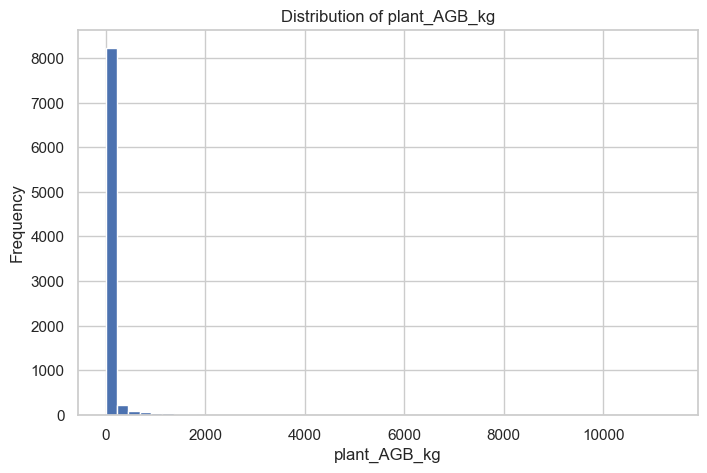

In [10]:
# Target distribution
plt.figure(figsize=(8, 5))
plt.hist(df["plant_AGB_kg"], bins=50)
plt.title("Distribution of plant_AGB_kg")
plt.xlabel("plant_AGB_kg")
plt.ylabel("Frequency")
plt.show()

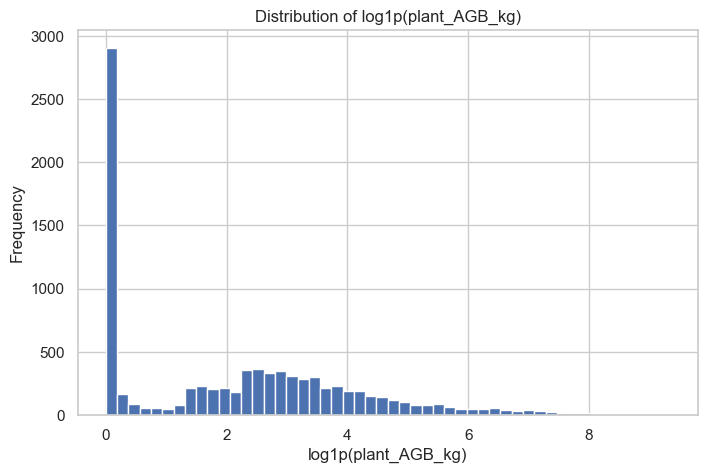

In [11]:
# log-transformed target distribution
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df["plant_AGB_kg"]), bins=50)
plt.title("Distribution of log1p(plant_AGB_kg)")
plt.xlabel("log1p(plant_AGB_kg)")
plt.ylabel("Frequency")
plt.show()

In [12]:
eo_cols = [
    "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",
    "NDVI", "MNDWI", "NBR", "EVI", "CLOUD_COVERAGE"
]

# Count unique EO combinations per plot
eo_variation = df.groupby("plot_id")[eo_cols].nunique()

print(eo_variation.head(10))

                      Blue  Green  Red  NIR  SWIR1  SWIR2  NDVI  MNDWI  NBR  \
plot_id                                                                       
ACA_Acarau Boca          3      4    3    3      3      4     5      6    5   
Arco_del_Espino_18_1     1      1    1    1      1      1     1      1    1   
Arco_del_Espino_18_2     1      1    1    1      1      1     1      1    1   
Arco_del_Espino_18_3     1      1    1    1      1      1     1      1    1   
Arco_del_Espino_18_4     1      1    1    1      1      1     1      1    1   
Arco_del_Espino_18_5     1      1    1    1      1      1     1      1    1   
Arco_del_Espino_18_6     1      1    1    1      1      1     1      1    1   
BAR_Barreto              5      5    5    5      5      6     6      6    6   
BOC_Boca Grande          0      0    0    0      0      0     0      0    0   
Batipa_2                 0      0    0    0      0      0     0      0    0   

                      EVI  CLOUD_COVERAGE  
plot_id

In [13]:
# EO aggregation
eo_cols = [
    "Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2",
    "NDVI", "MNDWI", "NBR", "EVI", "CLOUD_COVERAGE"
]

# Aggregate EO per plot (mean)
eo_agg = df.groupby("plot_id")[eo_cols].mean().reset_index()

# Merge back to original dataset
df_model = df.merge(eo_agg, on="plot_id", suffixes=("", "_agg"))

print(df_model.head())
print(df_model.shape)

      dataset       plot_id  start_date    end_date  latitude_x  longitude_x  \
0  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
1  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
2  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
3  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   
4  ElSalvador  El_Jobal_9_6  2017-01-01  2017-12-31    13.22736    -88.60437   

   diameter  height species  plant_AGB_kg  longitude_y  latitude_y  \
0      26.3    12.0  mangle    630.627596    -88.60437    13.22736   
1      28.6    14.0  mangle    784.223246    -88.60437    13.22736   
2      19.2     4.0  mangle    139.136548    -88.60437    13.22736   
3       6.2     8.0  mangle     14.726733    -88.60437    13.22736   
4       5.2     5.0  mangle      9.321734    -88.60437    13.22736   

                  time    Blue   Green     Red     NIR   SWIR1   SWIR2  \
0  2017-01-12 16:16:21  

## (b)	Data preparation

Let's log-transform the target variable to reduce skewness

In [97]:
# Prepare the features for modeling
df = df_model.copy()

# Target (log transform)
df["AGB_log"] = np.log1p(df["plant_AGB_kg"])


In [98]:
# EO features
eo_cols_agg = [
    "Blue_agg", "Green_agg", "Red_agg", "NIR_agg", "SWIR1_agg", "SWIR2_agg", "NDVI_agg", "MNDWI_agg", "NBR_agg", "EVI_agg", "CLOUD_COVERAGE_agg"]

# Categorical
cat_cols = ["species", "dataset"]

In [99]:
# Encode categorical vars
from sklearn.preprocessing import LabelEncoder

le_species = LabelEncoder()
le_dataset = LabelEncoder()

df["species_enc"] = le_species.fit_transform(df["species"])
df["dataset_enc"] = le_dataset.fit_transform(df["dataset"])

In [96]:
# Scale numeric features
from sklearn.preprocessing import StandardScaler

scaler_eo = StandardScaler()

X_eo = scaler_eo.fit_transform(df[eo_cols_agg])

X_species = df["species_enc"].values
X_dataset = df["dataset_enc"].values

y = df["AGB_log"].values

In [18]:
# train/test split 

plot_ids = df["plot_id"].unique()

train_plots, test_plots = train_test_split(plot_ids, test_size=0.2, random_state=42)

train_idx = df["plot_id"].isin(train_plots)
test_idx = df["plot_id"].isin(test_plots)

# Split inputs
X_eo_train, X_eo_test = X_eo[train_idx], X_eo[test_idx]
X_species_train, X_species_test = X_species[train_idx], X_species[test_idx]
X_dataset_train, X_dataset_test = X_dataset[train_idx], X_dataset[test_idx]

# Split target
y_train, y_test = y[train_idx], y[test_idx]

In [19]:
# train/val/test split by plot

plot_ids = df["plot_id"].unique()

train_plots, temp_plots = train_test_split(
    plot_ids, test_size=0.3, random_state=42
)

val_plots, test_plots = train_test_split(
    temp_plots, test_size=0.5, random_state=42
)

train_idx = df["plot_id"].isin(train_plots)
val_idx = df["plot_id"].isin(val_plots)
test_idx = df["plot_id"].isin(test_plots)

# EO features
X_eo_train, X_eo_val, X_eo_test = (
    X_eo[train_idx],
    X_eo[val_idx],
    X_eo[test_idx]
)

# Categorical
X_species_train, X_species_val, X_species_test = (
    X_species[train_idx],
    X_species[val_idx],
    X_species[test_idx]
)

X_dataset_train, X_dataset_val, X_dataset_test = (
    X_dataset[train_idx],
    X_dataset[val_idx],
    X_dataset[test_idx]
)

# Target
y_train, y_val, y_test = (
    y[train_idx],
    y[val_idx],
    y[test_idx]
)

## (c)	Modeling

## Model 1 -Baseline model


### Model Architecture without strusctural features (tree height and diameter)

EO branch         → Dense layers

Categorical branch→ Embeddings

→ Concatenate
→ Dense layers
→ AGB prediction
#

In [20]:
# 1st branch (Tree features)
#tree_input = layers.Input(shape=(2,), name="tree_input")
#x_tree = layers.Dense(32, activation="relu")(tree_input)
#x_tree = layers.Dense(16, activation="relu")(x_tree)

In [21]:
# 1sr branch (EO features)
eo_input = layers.Input(shape=(len(eo_cols_agg),), name="eo_input")
x_eo = layers.Dense(64, activation="relu")(eo_input)
x_eo = layers.Dense(32, activation="relu")(x_eo)

In [22]:
# Categorical embeddings
# species
species_input = layers.Input(shape=(1,), name="species_input")
species_emb = layers.Embedding(
    input_dim=df["species_enc"].nunique(),
    output_dim=4
)(species_input)
species_emb = layers.Flatten()(species_emb)



In [23]:
# dataset
dataset_input = layers.Input(shape=(1,), name="dataset_input")
dataset_emb = layers.Embedding(
    input_dim=df["dataset_enc"].nunique(),
    output_dim=3
)(dataset_input)
dataset_emb = layers.Flatten()(dataset_emb)

In [24]:
# fusion layer
combined = layers.concatenate([
    x_eo,
    species_emb,
    dataset_emb
])

In [25]:
# Lets use regularization
x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001))(combined)

x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)

output = layers.Dense(1, activation="linear")(x)



In [26]:
# Model building

model_v1 = Model(
    inputs=[eo_input, species_input, dataset_input],
    outputs=output
)

model_v1.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

model_v1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eo_input            │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dataset_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        768 │ eo_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 4)      │         72 │ species_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 3)      │         51 │ dataset_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 39)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      5,120 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         65 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,412 (64.11 KB)

 Trainable params: 16,412 (64.11 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Training
history_v1 = model_v1.fit(
    [X_eo_train, X_species_train, X_dataset_train],
    y_train,
    validation_data=(
        [X_eo_val, X_species_val, X_dataset_val],
        y_val
    ),
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3)
    ]
)


Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.2983 - mae: 1.6008 - val_loss: 0.7280 - val_mae: 1.0741 - learning_rate: 0.0010
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7009 - mae: 1.0506 - val_loss: 0.6980 - val_mae: 1.0502 - learning_rate: 0.0010
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6867 - mae: 1.0457 - val_loss: 0.7105 - val_mae: 1.0655 - learning_rate: 0.0010
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6811 - mae: 1.0618 - val_loss: 0.6913 - val_mae: 1.0711 - learning_rate: 0.0010
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6636 - mae: 1.0421 - val_loss: 0.6875 - val_mae: 1.0680 - learning_rate: 0.0010
Epoch 6/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6742 - mae: 1.0573 - val_loss: 0.6739 - val_mae: 1.0411 - learning_rate: 0.0010
Epoch 7/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6435 - mae: 1.0220 - val_loss: 0.6780 - val_mae: 1.0594 - learning_rate: 0.0010
Epoch 

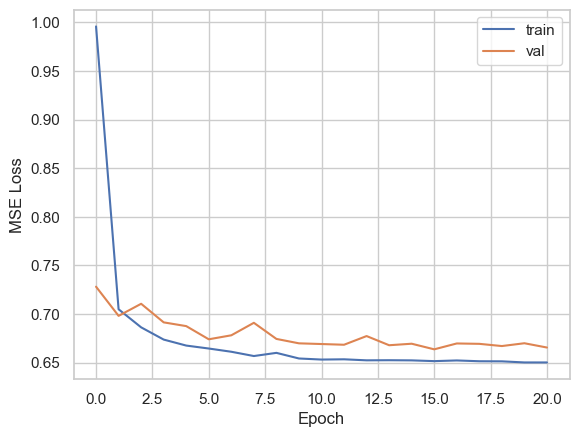

In [29]:
# Plot Plot train/validation loss
plt.plot(history_v1.history['loss'], label='train')
plt.plot(history_v1.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

The model converged well, with rapid initial improvement followed by steady refinement. Validation performance remained stable throughout training  indicating good generalization with only mild overfitting.

In [30]:
# Calculate Test performance metrics

y_pred_v1 = model_v1.predict(
    [X_eo_test, X_species_test, X_dataset_test])

y_pred_v1_real = np.expm1(y_pred_v1).ravel()
y_test_real = np.expm1(y_test)

rmse_v1 = np.sqrt(mean_squared_error(y_test_real, y_pred_v1_real))
mae_v1 = mean_absolute_error(y_test_real, y_pred_v1_real)
r2_v1 = r2_score(y_test_real, y_pred_v1_real)

print("RMSE:", rmse_v1)
print("MAE:", mae_v1)
print("R2:", r2_v1)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
RMSE: 411.7038406301519
MAE: 88.17504888139713
R2: -0.03525789760330866


In [32]:
# Calculate Test performance metrics

y_pred_v1 = model_v1.predict(
    [X_eo_test, X_species_test, X_dataset_test])

y_pred_v1_real = np.expm1(y_pred_v1).ravel()
y_test_real = np.expm1(y_test)

rmse_v1 = np.sqrt(mean_squared_error(y_test_real, y_pred_v1_real))
mae_v1 = mean_absolute_error(y_test_real, y_pred_v1_real)
r2_v1 = r2_score(y_test_real, y_pred_v1_real)

print("RMSE:", rmse_v1)
print("MAE:", mae_v1)
print("R2:", r2_v1)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
RMSE: 411.7038406301519
MAE: 88.17504888139713
R2: -0.03525789760330866


In [33]:
# Predict (log scale output from model)
y_pred_v1 = model_v1.predict(
    [X_eo_test, X_species_test, X_dataset_test]
)

# --- Convert to original scale ---
y_pred_v1_real = np.expm1(y_pred_v1).ravel()
y_test_real = np.expm1(y_test)

# --- Original scale metrics ---
rmse_v1 = np.sqrt(mean_squared_error(y_test_real, y_pred_v1_real))
mae_v1 = mean_absolute_error(y_test_real, y_pred_v1_real)
r2_v1 = r2_score(y_test_real, y_pred_v1_real)

# --- Log scale metrics ---
y_pred_v1_log = y_pred_v1.ravel()

rmse_v1_log = np.sqrt(mean_squared_error(y_test, y_pred_v1_log))
mae_v1_log = mean_absolute_error(y_test, y_pred_v1_log)
r2_v1_log = r2_score(y_test, y_pred_v1_log)

# --- Print results ---
print("Model v1 RMSE:", rmse_v1)
print("Model v1 MAE:", mae_v1)
print("Model v1 R2:", r2_v1)

print("Model v1 Log RMSE:", rmse_v1_log)
print("Model v1 Log MAE:", mae_v1_log)
print("Model v1 R2 (log):", r2_v1_log)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step  
Model v1 RMSE: 411.7038406301519
Model v1 MAE: 88.17504888139713
Model v1 R2: -0.03525789760330866
Model v1 Log RMSE: 1.52666205292217
Model v1 Log MAE: 1.0999341838401233
Model v1 R2 (log): 0.34893084034555655


The EO-only model achieved an R² of 0.35 in log-transformed space, indicating that spectral and derived interaction features contain substantial predictive information about biomass. However, performance in the original scale remained limited, highlighting the challenges of predicting absolute biomass from EO data alone due to the skewed distribution of AGB and the absence of structural variables.

In [34]:
# Fine tune regularization

def build_model(l2_value, eo_dim, species_dim, dataset_dim):
    eo_input = layers.Input(shape=(eo_dim,), name="eo_input")
    species_input = layers.Input(shape=(species_dim,), name="species_input")
    dataset_input = layers.Input(shape=(dataset_dim,), name="dataset_input")

    combined = layers.concatenate([
        eo_input,
        species_input,
        dataset_input
    ])

    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_value)
    )(combined)

    x = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_value)
    )(x)

    output = layers.Dense(1, activation="linear")(x)

    model = Model(
        inputs=[eo_input, species_input, dataset_input],
        outputs=output
    )

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae", RootMeanSquaredError(name="rmse")]
    )

    return model

In [35]:
l2_values = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]

In [36]:
# Reshape 1D inputs to 2D
# Reshape 1D categorical inputs to 2D
X_species_train = X_species_train.reshape(-1, 1)
X_species_val = X_species_val.reshape(-1, 1)
X_species_test = X_species_test.reshape(-1, 1)

X_dataset_train = X_dataset_train.reshape(-1, 1)
X_dataset_val = X_dataset_val.reshape(-1, 1)
X_dataset_test = X_dataset_test.reshape(-1, 1)

# Dimensions
eo_dim = X_eo_train.shape[1]
species_dim = X_species_train.shape[1]
dataset_dim = X_dataset_train.shape[1]

# Compute EO column means from training data only
eo_col_means = np.nanmean(X_eo_train, axis=0)

# Fill NaNs in train
inds_train = np.where(np.isnan(X_eo_train))
X_eo_train[inds_train] = np.take(eo_col_means, inds_train[1])

# Fill NaNs in validation
inds_val = np.where(np.isnan(X_eo_val))
X_eo_val[inds_val] = np.take(eo_col_means, inds_val[1])

# Fill NaNs in test
inds_test = np.where(np.isnan(X_eo_test))
X_eo_test[inds_test] = np.take(eo_col_means, inds_test[1])

In [37]:
results = []

for l2_val in l2_values:
    print(f"\nTraining model with L2 = {l2_val}")

    model = build_model(
        l2_val,
        eo_dim,
        species_dim,
        dataset_dim
    )

    history = model.fit(
        [X_eo_train, X_species_train, X_dataset_train],
        y_train,
        validation_data=(
            [X_eo_val, X_species_val, X_dataset_val],
            y_val
        ),
        epochs=50,
        batch_size=32,
        callbacks=[
            EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    results.append({
        "l2": l2_val,
        "best_val_loss": min(history.history["val_loss"]),
        "best_val_mae": min(history.history["val_mae"]),
        "best_val_rmse": min(history.history["val_rmse"])
    })

results_df = pd.DataFrame(results)
print(results_df)


Training model with L2 = 0.0

Training model with L2 = 1e-05

Training model with L2 = 0.0001

Training model with L2 = 0.001

Training model with L2 = 0.01
        l2  best_val_loss  best_val_mae  best_val_rmse
0  0.00000       1.679955      0.842178       1.296131
1  0.00001       1.667605      0.846462       1.290789
2  0.00010       1.755496      0.878334       1.320137
3  0.00100       1.745772      0.860008       1.289927
4  0.01000       1.835889      0.861317       1.286337


## Model 2 - Tuned

In [38]:
# Dense layers with best L2
x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-05)
)(combined)

x = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(1e-05)
)(x)

output = layers.Dense(1, activation="linear")(x)

# Model (no tree_input)
model_v2 = Model(
    inputs=[eo_input, species_input, dataset_input],
    outputs=output
)

# Compile 
model_v2.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=[
        "mae",
        RootMeanSquaredError(name="rmse")
    ]
)

In [39]:
model_v2.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eo_input            │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dataset_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        768 │ eo_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 4)      │         72 │ species_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 3)      │         51 │ dataset_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 39)        │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 128)       │      5,120 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 64)        │      8,256 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 1)         │         65 │ dense_21[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,412 (64.11 KB)

 Trainable params: 16,412 (64.11 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Training
history_v2 = model_v2.fit(
    [X_eo_train, X_species_train, X_dataset_train],
    y_train,
    validation_data=(
        [X_eo_val, X_species_val, X_dataset_val],
        y_val
    ),
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3)
    ]
)

Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1.1382 - mae: 1.5356 - rmse: 2.0865 - val_loss: 0.6928 - val_mae: 1.0570 - val_rmse: 1.5754 - learning_rate: 0.0010
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6527 - mae: 1.0506 - rmse: 1.4118 - val_loss: 0.6861 - val_mae: 1.0663 - val_rmse: 1.5523 - learning_rate: 0.0010
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6464 - mae: 1.0419 - rmse: 1.4101 - val_loss: 0.6885 - val_mae: 1.0765 - val_rmse: 1.5531 - learning_rate: 0.0010
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6525 - mae: 1.0446 - rmse: 1.4252 - val_loss: 0.6882 - val_mae: 1.0919 - val_rmse: 1.5329 - learning_rate: 0.0010
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6372 - mae: 1.0344 - rmse: 1.3944 - val_loss: 0.7065 - val_mae: 1.0788 - val_rmse: 1.5983 - learning_rate: 0.0010
Epoch 6/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6357 - mae: 1.0314 - rmse: 1.3931 - val_loss: 0.6891 - val

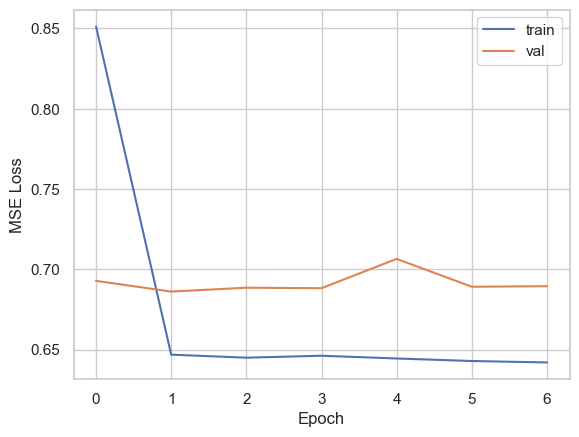

In [41]:
# Plot Plot train/validation loss
plt.plot(history_v2.history['loss'], label='train')
plt.plot(history_v2.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

The model converges quickly and maintains stable validation performance. Learning rate decay improves final generalization, and the small gap between training and validation metrics indicates effective regularization without significant overfitting.

In [42]:
# Calculate Test performance metrics

# Predict (log scale output from model)
y_pred_v2 = model_v2.predict(
    [X_eo_test, X_species_test, X_dataset_test]
)

# --- Convert to original scale ---
y_pred_v2_real = np.expm1(y_pred_v2).ravel()
y_test_real = np.expm1(y_test)

# --- Original scale metrics ---
rmse_v2 = np.sqrt(mean_squared_error(y_test_real, y_pred_v2_real))
mae_v2 = mean_absolute_error(y_test_real, y_pred_v2_real)
r2_v2 = r2_score(y_test_real, y_pred_v2_real)

# --- Log scale metrics ---
y_pred_v2_log = y_pred_v2.ravel()

rmse_v2_log = np.sqrt(mean_squared_error(y_test, y_pred_v2_log))
mae_v2_log = mean_absolute_error(y_test, y_pred_v2_log)
r2_v2_log = r2_score(y_test, y_pred_v2_log)

# --- Print results ---
print("Model v2 RMSE:", rmse_v2)
print("Model v2 MAE:", mae_v2)
print("Model v2 R2:", r2_v2)

print("Model v2 Log RMSE:", rmse_v2_log)
print("Model v2 Log MAE:", mae_v2_log)
print("Model v2 R2 (log):", r2_v2_log)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
Model v2 RMSE: 412.5050174375852
Model v2 MAE: 88.5962435970119
Model v2 R2: -0.03929104748743728
Model v2 Log RMSE: 1.5654323151099414
Model v2 Log MAE: 1.1290726066022376
Model v2 R2 (log): 0.31544256514554747


## Model 3 - Additional features 

In [43]:
df_v3 = df_model.copy()

# Target log
df_v3["AGB_log"] = np.log1p(df_v3["plant_AGB_kg"])

# EO features only
eo_cols_agg = [
    "Blue_agg", "Green_agg", "Red_agg", "NIR_agg",
    "SWIR1_agg", "SWIR2_agg",
    "NDVI_agg", "MNDWI_agg", "NBR_agg", "EVI_agg",
    "CLOUD_COVERAGE_agg"
]

In [57]:
# Define feature groups
#tree_cols_v3 = [
#    "diameter",
#    "height",
#    "dbh_height",
#    "dbh_sq",
#    "log_diameter",
#    "log_height"
#]

eo_cols_agg = [
    "Blue_agg", "Green_agg", "Red_agg", "NIR_agg",
    "SWIR1_agg", "SWIR2_agg",
    "NDVI_agg", "MNDWI_agg", "NBR_agg", "EVI_agg",
    "CLOUD_COVERAGE_agg"
]

In [45]:
# Encode categorical variables 
le_species_v3 = LabelEncoder()
le_dataset_v3 = LabelEncoder()

df_v3["species_enc"] = le_species_v3.fit_transform(df_v3["species"]).astype("int32")
df_v3["dataset_enc"] = le_dataset_v3.fit_transform(df_v3["dataset"]).astype("int32")

In [46]:
# Clean data
df_v3 = df_v3.replace([np.inf, -np.inf], np.nan)

required_cols = eo_cols_agg + [
    "species_enc", "dataset_enc", "AGB_log", "plot_id"
]

df_v3 = df_v3.dropna(subset=required_cols).copy()

print("Shape after cleaning:", df_v3.shape)

Shape after cleaning: (8160, 38)


In [47]:
# Prepare inputs

scaler_tree_v3 = StandardScaler()
scaler_eo_v3 = StandardScaler()

X_eo_v3 = scaler_eo_v3.fit_transform(df_v3[eo_cols_agg])

X_species_v3 = df_v3["species_enc"].values.reshape(-1, 1)
X_dataset_v3 = df_v3["dataset_enc"].values.reshape(-1, 1)

y_v3 = df_v3["AGB_log"].values

In [48]:
# Safety checks 

print("NaNs in X_eo:", np.isnan(X_eo_v3).sum())
print("NaNs in y:", np.isnan(y_v3).sum())

NaNs in X_eo: 0
NaNs in y: 0


In [49]:
# Split by plot_id

plot_ids = df_v3["plot_id"].unique()

train_plots, temp_plots = train_test_split(
    plot_ids, test_size=0.3, random_state=42
)

val_plots, test_plots = train_test_split(
    temp_plots, test_size=0.5, random_state=42
)

train_idx_v3 = df_v3["plot_id"].isin(train_plots)
val_idx_v3 = df_v3["plot_id"].isin(val_plots)
test_idx_v3 = df_v3["plot_id"].isin(test_plots)

In [50]:
# Split arrays (no tree features)

X_eo_train_v3 = X_eo_v3[train_idx_v3]
X_eo_val_v3 = X_eo_v3[val_idx_v3]
X_eo_test_v3 = X_eo_v3[test_idx_v3]

X_species_train_v3 = X_species_v3[train_idx_v3]
X_species_val_v3 = X_species_v3[val_idx_v3]
X_species_test_v3 = X_species_v3[test_idx_v3]

X_dataset_train_v3 = X_dataset_v3[train_idx_v3]
X_dataset_val_v3 = X_dataset_v3[val_idx_v3]
X_dataset_test_v3 = X_dataset_v3[test_idx_v3]

y_train_v3 = y_v3[train_idx_v3]
y_val_v3 = y_v3[val_idx_v3]
y_test_v3 = y_v3[test_idx_v3]

In [51]:
# Embedding sizes
n_species_v3 = int(df_v3["species_enc"].max()) + 1
n_dataset_v3 = int(df_v3["dataset_enc"].max()) + 1

print("n_species:", n_species_v3)
print("n_dataset:", n_dataset_v3)

n_species: 18
n_dataset: 15


In [52]:
# Build model_v3 (no tree features)

# EO branch
eo_input = layers.Input(shape=(len(eo_cols_agg),), name="eo_input")
x_eo = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.01))(eo_input)
x_eo = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.01))(x_eo)

# species embedding
species_input = layers.Input(shape=(1,), name="species_input")
species_emb = layers.Embedding(n_species_v3, 4)(species_input)
species_emb = layers.Flatten()(species_emb)

# dataset embedding
dataset_input = layers.Input(shape=(1,), name="dataset_input")
dataset_emb = layers.Embedding(n_dataset_v3, 3)(dataset_input)
dataset_emb = layers.Flatten()(dataset_emb)

# fusion (no x_tree)
combined = layers.concatenate([x_eo, species_emb, dataset_emb])

# dense layers
x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.01))(combined)
x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.01))(x)

output = layers.Dense(1, activation="linear")(x)

# model
model_v3 = Model(
    inputs=[eo_input, species_input, dataset_input],
    outputs=output
)

model_v3.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae"]
)

model_v3.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eo_input            │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dataset_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 64)        │        768 │ eo_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 4)      │         72 │ species_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 3)      │         45 │ dataset_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 32)        │      2,080 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 4)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 3)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 39)        │          0 │ dense_24[0][0],   │
│ (Concatenate)       │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 128)       │      5,120 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 64)        │      8,256 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1)         │         65 │ dense_26[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,406 (64.09 KB)

 Trainable params: 16,406 (64.09 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Model training
history_v3 = model_v3.fit(
    [ X_eo_train_v3, X_species_train_v3, X_dataset_train_v3],
    y_train_v3,
    validation_data=(
        [X_eo_val_v3, X_species_val_v3, X_dataset_val_v3],
        y_val_v3
    ),
    epochs=50,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.3)
    ]
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2.3371 - mae: 1.3525 - val_loss: 1.2278 - val_mae: 1.2157 - learning_rate: 0.0010
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8989 - mae: 0.8691 - val_loss: 0.9626 - val_mae: 1.1740 - learning_rate: 0.0010
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7190 - mae: 0.8543 - val_loss: 0.8862 - val_mae: 1.1794 - learning_rate: 0.0010
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6343 - mae: 0.8359 - val_loss: 0.8836 - val_mae: 1.2027 - learning_rate: 0.0010
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6425 - mae: 0.8799 - val_loss: 0.8225 - val_mae: 1.1627 - learning_rate: 0.0010
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5819 - mae: 0.8282 - val_loss: 0.8136 - val_mae: 1.1683 - learning_rate: 0.0010
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5696 - mae: 0.8273 - val_loss: 0.7871 - val_mae: 1.1491 - learning_rate: 0.0010
Epoch 

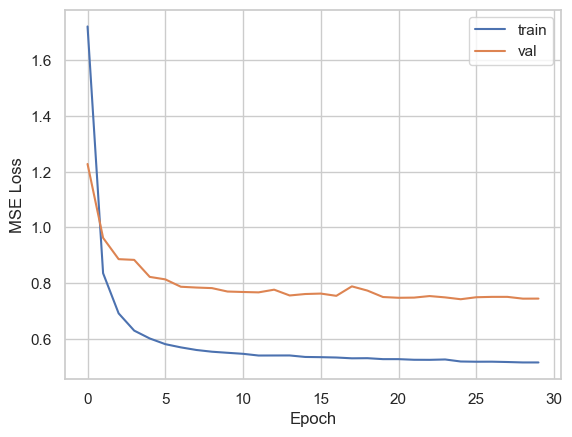

In [54]:
# Plot Plot train/validation loss
plt.plot(history_v3.history['loss'], label='train')
plt.plot(history_v3.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [55]:
# Predict (log scale output from model)
y_pred_v3 = model_v3.predict(
    [X_eo_test_v3, X_species_test_v3, X_dataset_test_v3]
)

# --- Convert to original scale ---
y_pred_v3_real = np.expm1(y_pred_v3).ravel()
y_test_real_v3 = np.expm1(y_test_v3)

# --- Original scale metrics ---
rmse_v3 = np.sqrt(mean_squared_error(y_test_real_v3, y_pred_v3_real))
mae_v3 = mean_absolute_error(y_test_real_v3, y_pred_v3_real)
r2_v3 = r2_score(y_test_real_v3, y_pred_v3_real)

# --- Log scale metrics ---
y_pred_v3_log = y_pred_v3.ravel()

rmse_v3_log = np.sqrt(mean_squared_error(y_test_v3, y_pred_v3_log))
mae_v3_log = mean_absolute_error(y_test_v3, y_pred_v3_log)
r2_v3_log = r2_score(y_test_v3, y_pred_v3_log)

# --- Print results ---
print("Model v3 RMSE:", rmse_v3)
print("Model v3 MAE:", mae_v3)
print("Model v3 R2:", r2_v3)

print("Model v3 Log RMSE:", rmse_v3_log)
print("Model v3 Log MAE:", mae_v3_log)
print("Model v3 R2 (log):", r2_v3_log)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
Model v3 RMSE: 488.91840492279215
Model v3 MAE: 90.05564011281895
Model v3 R2: -0.02100536028164024
Model v3 Log RMSE: 1.5254427626850462
Model v3 Log MAE: 1.115751178645391
Model v3 R2 (log): 0.1952594015965532


## Add EO derived features

In [58]:
df_v3["NDVI_EVI"] = df_v3["NDVI_agg"] * df_v3["EVI_agg"]
df_v3["NIR_Red_ratio"] = df_v3["NIR_agg"] / (df_v3["Red_agg"] + 1e-6)
df_v3["SWIR_NIR_ratio"] = df_v3["SWIR1_agg"] / (df_v3["NIR_agg"] + 1e-6)
df_v3["NIR_SWIR_diff"] = df_v3["NIR_agg"] - df_v3["SWIR1_agg"]
df_v3["Veg_Index_Mean"] = df_v3[["NDVI_agg", "EVI_agg", "NBR_agg"]].mean(axis=1)
df_v3["Water_Index_Mean"] = df_v3[["MNDWI_agg", "CLOUD_COVERAGE_agg"]].mean(axis=1)

In [59]:
# Try a new model with BatchNorm + Dropout

eo_input = layers.Input(shape=(len(eo_cols_agg),), name="eo_input")

x_eo = layers.Dense(128, activation="relu")(eo_input)
x_eo = layers.BatchNormalization()(x_eo)
x_eo = layers.Dropout(0.2)(x_eo)

x_eo = layers.Dense(64, activation="relu")(x_eo)
x_eo = layers.BatchNormalization()(x_eo)
x_eo = layers.Dropout(0.2)(x_eo)

x_eo = layers.Dense(32, activation="relu")(x_eo)

species_input = layers.Input(shape=(1,), name="species_input")
species_emb = layers.Embedding(n_species_v3, 8)(species_input)
species_emb = layers.Flatten()(species_emb)

dataset_input = layers.Input(shape=(1,), name="dataset_input")
dataset_emb = layers.Embedding(n_dataset_v3, 4)(dataset_input)
dataset_emb = layers.Flatten()(dataset_emb)

combined = layers.concatenate([x_eo, species_emb, dataset_emb])

x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001))(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001))(x)

output = layers.Dense(1, activation="linear")(x)

model_v4 = Model(
    inputs=[eo_input, species_input, dataset_input],
    outputs=output
)

model_v4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", RootMeanSquaredError(name="rmse")]
)

In [60]:

history_v4 = model_v4.fit(
    [X_eo_train_v3, X_species_train_v3, X_dataset_train_v3],
    y_train_v3,
    validation_data=(
        [X_eo_val_v3, X_species_val_v3, X_dataset_val_v3],
        y_val_v3
    ),
    epochs=100,
    batch_size=32,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.2008 - mae: 1.4745 - rmse: 1.9749 - val_loss: 1.0954 - val_mae: 1.4228 - val_rmse: 1.8025
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7621 - mae: 1.0047 - rmse: 1.3871 - val_loss: 0.9021 - val_mae: 1.2092 - val_rmse: 1.5760
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6931 - mae: 0.9339 - rmse: 1.2998 - val_loss: 0.8666 - val_mae: 1.1275 - val_rmse: 1.5742
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6657 - mae: 0.9046 - rmse: 1.2939 - val_loss: 0.8706 - val_mae: 1.1564 - val_rmse: 1.5968
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6072 - mae: 0.8457 - rmse: 1.2115 - val_loss: 0.8941 - val_mae: 1.2065 - val_rmse: 1.6388
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6040 - mae: 0.8462 - rmse: 1.2144 - val_loss: 0.8367 - val_mae: 1.1505 - val_rmse: 1.5533
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5874 - mae: 0.8289 

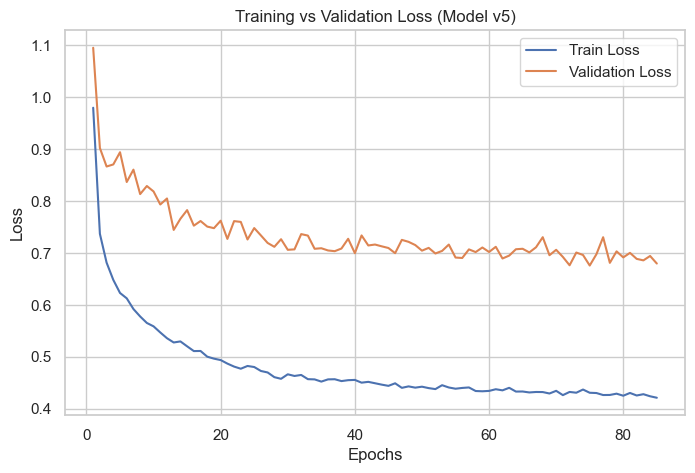

In [63]:

# Extract loss values
train_loss = history_v4.history["loss"]
val_loss = history_v4.history["val_loss"]

epochs = range(1, len(train_loss) + 1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Model v5)")
plt.legend()
plt.grid(True)

plt.show()

In [66]:
y_pred_log = model_v4.predict(
    [X_eo_test_v3, X_species_test_v3, X_dataset_test_v3]
).ravel()

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [67]:
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_v3)

In [89]:
rmse_v4_log = np.sqrt(mean_squared_error(y_test_v3, y_pred_v3_log))
mae_v4_log = mean_absolute_error(y_test_v3, y_pred_v3_log)

print("Log RMSE:", rmse_v4_log)
print("Log MAE:", mae_v4_log)

# Log scale
r2_v4_log = r2_score(y_test_v3, y_pred_v3_log)
print("R2 (log):", r2_v4_log)

Log RMSE: 1.5254427626850462
Log MAE: 1.115751178645391
R2 (log): 0.1952594015965532


## New features

In [73]:
# --- EO interaction features ---

eps = 1e-6  # avoid division by zero

df_v3["NIR_Red_ratio"] = df_v3["NIR_agg"] / (df_v3["Red_agg"] + eps)
df_v3["SWIR1_NIR_ratio"] = df_v3["SWIR1_agg"] / (df_v3["NIR_agg"] + eps)

df_v3["NDVI_EVI"] = df_v3["NDVI_agg"] * df_v3["EVI_agg"]
df_v3["NDVI_NBR"] = df_v3["NDVI_agg"] * df_v3["NBR_agg"]

df_v3["NIR_SWIR_diff"] = df_v3["NIR_agg"] - df_v3["SWIR1_agg"]
df_v3["Red_SWIR_diff"] = df_v3["Red_agg"] - df_v3["SWIR2_agg"]

df_v3["Veg_Index_Mean"] = df_v3[["NDVI_agg", "EVI_agg", "NBR_agg"]].mean(axis=1)
df_v3["Water_Index_Mean"] = df_v3[["MNDWI_agg", "CLOUD_COVERAGE_agg"]].mean(axis=1)

df_v3["NDVI_squared"] = df_v3["NDVI_agg"] ** 2
df_v3["EVI_squared"] = df_v3["EVI_agg"] ** 2

In [74]:
eo_cols_agg_v5 = [
    "Blue_agg", "Green_agg", "Red_agg", "NIR_agg",
    "SWIR1_agg", "SWIR2_agg",
    "NDVI_agg", "MNDWI_agg", "NBR_agg", "EVI_agg",
    "CLOUD_COVERAGE_agg",

    # new features
    "NIR_Red_ratio",
    "SWIR1_NIR_ratio",
    "NDVI_EVI",
    "NDVI_NBR",
    "NIR_SWIR_diff",
    "Red_SWIR_diff",
    "Veg_Index_Mean",
    "Water_Index_Mean",
    "NDVI_squared",
    "EVI_squared"
]

In [77]:
# scale
scaler_eo_v5 = StandardScaler()
X_eo_v5 = scaler_eo_v5.fit_transform(df_v3[eo_cols_agg_v5])

# splits
X_eo_train_v5 = X_eo_v5[train_idx_v3]
X_eo_val_v5 = X_eo_v5[val_idx_v3]
X_eo_test_v5 = X_eo_v5[test_idx_v3]

In [78]:
# Build model_v5 with EO interaction features

eo_input_v5 = layers.Input(shape=(len(eo_cols_agg_v5),), name="eo_input_v5")

x_eo = layers.Dense(128, activation="relu")(eo_input_v5)
x_eo = layers.BatchNormalization()(x_eo)
x_eo = layers.Dropout(0.2)(x_eo)

x_eo = layers.Dense(64, activation="relu")(x_eo)
x_eo = layers.BatchNormalization()(x_eo)
x_eo = layers.Dropout(0.2)(x_eo)

x_eo = layers.Dense(32, activation="relu")(x_eo)

species_input_v5 = layers.Input(shape=(1,), name="species_input_v5")
species_emb = layers.Embedding(n_species_v3, 8)(species_input_v5)
species_emb = layers.Flatten()(species_emb)

dataset_input_v5 = layers.Input(shape=(1,), name="dataset_input_v5")
dataset_emb = layers.Embedding(n_dataset_v3, 4)(dataset_input_v5)
dataset_emb = layers.Flatten()(dataset_emb)

combined = layers.concatenate([x_eo, species_emb, dataset_emb])

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(
    64,
    activation="relu",
    kernel_regularizer=regularizers.l2(0.001)
)(x)

output = layers.Dense(1, activation="linear")(x)

model_v5 = Model(
    inputs=[eo_input_v5, species_input_v5, dataset_input_v5],
    outputs=output
)

model_v5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", RootMeanSquaredError(name="rmse")]
)

model_v5.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eo_input_v5         │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 128)       │      2,816 │ eo_input_v5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_34[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_35[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ species_input_v5    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dataset_input_v5    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 1, 8)      │        144 │ species_input_v5… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 1, 4)      │         60 │ dataset_input_v5… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 32)        │      2,080 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 8)         │          0 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 4)         │          0 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 44)        │          0 │ dense_36[0][0],   │
│ (Concatenate)       │                   │            │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 128)       │      5,760 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_37[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 64)        │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 1)         │         65 │ dense_38[0][0]  

 Total params: 28,717 (112.18 KB)

 Trainable params: 28,077 (109.68 KB)

 Non-trainable params: 640 (2.50 KB)

In [79]:
history_v5 = model_v5.fit(
    [X_eo_train_v5, X_species_train_v3, X_dataset_train_v3],
    y_train_v3,
    validation_data=(
        [X_eo_val_v5, X_species_val_v3, X_dataset_val_v3],
        y_val_v3
    ),
    epochs=100,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1.1039 - mae: 1.3691 - rmse: 1.8357 - val_loss: 1.1611 - val_mae: 1.4782 - val_rmse: 1.9451
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7366 - mae: 0.9735 - rmse: 1.3483 - val_loss: 0.9674 - val_mae: 1.2757 - val_rmse: 1.7409
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7021 - mae: 0.9387 - rmse: 1.3347 - val_loss: 0.9839 - val_mae: 1.2742 - val_rmse: 1.8196
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6395 - mae: 0.8796 - rmse: 1.2470 - val_loss: 0.9594 - val_mae: 1.2215 - val_rmse: 1.7483
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6533 - mae: 0.8966 - rmse: 1.2728 - val_loss: 1.0200 - val_mae: 1.3006 - val_rmse: 1.8576
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6138 - mae: 0.8548 - rmse: 1.2309 - val_loss: 0.9306 - val_mae: 1.2360 - val_rmse: 1.7203
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5999 - mae: 0.8460 

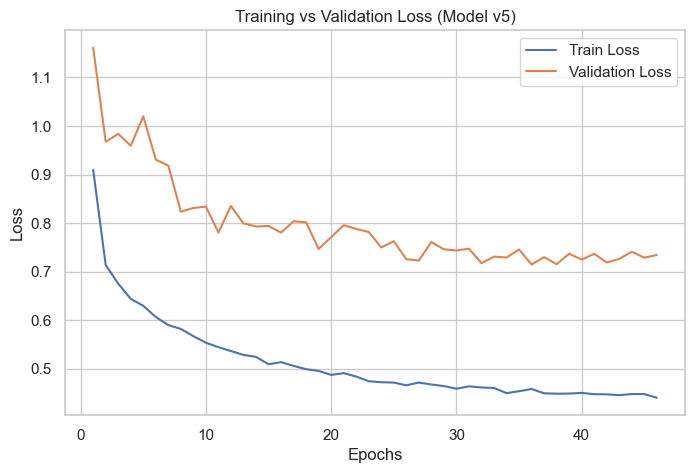

In [80]:


# Extract loss values
train_loss = history_v5.history["loss"]
val_loss = history_v5.history["val_loss"]

epochs = range(1, len(train_loss) + 1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Model v5)")
plt.legend()
plt.grid(True)

plt.show()

In [81]:
y_pred_v5_log = model_v5.predict(
    [X_eo_test_v5, X_species_test_v3, X_dataset_test_v3]
).ravel()

y_pred_v5 = np.expm1(y_pred_v5_log)
y_test_real_v5 = np.expm1(y_test_v3)

rmse_v5 = np.sqrt(mean_squared_error(y_test_real_v5, y_pred_v5))
mae_v5 = mean_absolute_error(y_test_real_v5, y_pred_v5)
r2_v5 = r2_score(y_test_real_v5, y_pred_v5)

rmse_v5_log = np.sqrt(mean_squared_error(y_test_v3, y_pred_v5_log))
mae_v5_log = mean_absolute_error(y_test_v3, y_pred_v5_log)
r2_v5_log = r2_score(y_test_v3, y_pred_v5_log)

print("Model v5 RMSE:", rmse_v5)
print("Model v5 MAE:", mae_v5)
print("Model v5 R2:", r2_v5)

print("Model v5 Log RMSE:", rmse_v5_log)
print("Model v5 Log MAE:", mae_v5_log)
print("Model v5 R2 (log):", r2_v5_log)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
Model v5 RMSE: 486.8268243248862
Model v5 MAE: 89.56995536249039
Model v5 R2: -0.012288375439900134
Model v5 Log RMSE: 1.4489350110357972
Model v5 Log MAE: 1.0275683883184077
Model v5 R2 (log): 0.2739577547958686


Adding interaction features improved the model’s ability to extract signal from EO data, increasing R² in log space from 0.20 to 0.27. However, performance in the original scale remains limited, suggesting that EO features alone are insufficient to fully capture biomass variability.


## Weighted model

In [82]:
# Compute sample weights 

y_train_real_v6 = np.expm1(y_train_v3)

# sqrt weighting (more stable)
sample_weights_v6 = np.sqrt(y_train_real_v6)

# normalize
sample_weights_v6 = sample_weights_v6 / np.mean(sample_weights_v6)

# clip to avoid extreme influence
sample_weights_v6 = np.clip(sample_weights_v6, 0.5, 3.0)

In [83]:
history_v6 = model_v5.fit(
    [X_eo_train_v5, X_species_train_v3, X_dataset_train_v3],
    y_train_v3,
    sample_weight=sample_weights_v6,
    validation_data=(
        [X_eo_val_v5, X_species_val_v3, X_dataset_val_v3],
        y_val_v3
    ),
    epochs=100,
    batch_size=32,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    ],
    verbose=1
)

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5828 - mae: 0.7955 - rmse: 1.1535 - val_loss: 0.7298 - val_mae: 1.1001 - val_rmse: 1.5130
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5758 - mae: 0.8376 - rmse: 1.2177 - val_loss: 0.7054 - val_mae: 1.0813 - val_rmse: 1.4798
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5813 - mae: 0.8483 - rmse: 1.2323 - val_loss: 0.7264 - val_mae: 1.0960 - val_rmse: 1.4844
Epoch 4/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5526 - mae: 0.8427 - rmse: 1.2261 - val_loss: 0.7057 - val_mae: 1.0806 - val_rmse: 1.4824
Epoch 5/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5838 - mae: 0.8399 - rmse: 1.2459 - val_loss: 0.6929 - val_mae: 1.0666 - val_rmse: 1.4629
Epoch 6/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5765 - mae: 0.8272 - rmse: 1.2034 - val_loss: 0.7658 - val_mae: 1.1524 - val_rmse: 1.5716
Epoch 7/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5428 - mae: 0.8359 

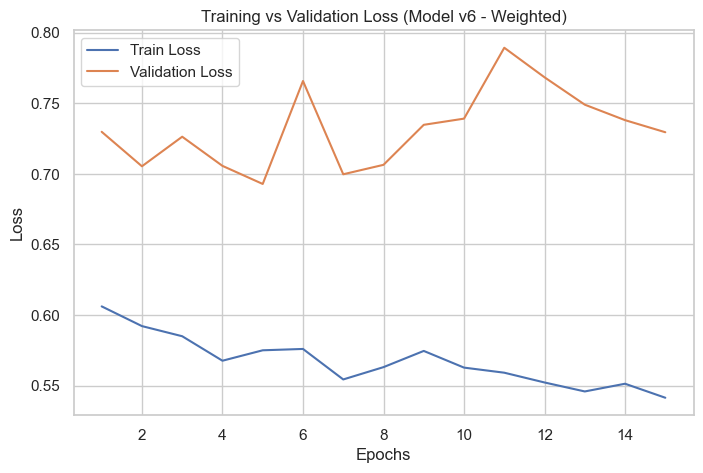

In [84]:


# Extract values
train_loss = history_v6.history["loss"]
val_loss = history_v6.history["val_loss"]

epochs = range(1, len(train_loss) + 1)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Model v6 - Weighted)")
plt.legend()
plt.grid(True)

plt.show()

In [85]:
# Eval
y_pred_v6_log = model_v5.predict(
    [X_eo_test_v5, X_species_test_v3, X_dataset_test_v3]
).ravel()

# convert to original scale
y_pred_v6 = np.expm1(y_pred_v6_log)
y_test_real_v6 = np.expm1(y_test_v3)

# Calculate Test performance metrics
rmse_v6 = np.sqrt(mean_squared_error(y_test_real_v6, y_pred_v6))
mae_v6 = mean_absolute_error(y_test_real_v6, y_pred_v6)
r2_v6 = r2_score(y_test_real_v6, y_pred_v6)

# log-scale metrics
rmse_v6_log = np.sqrt(mean_squared_error(y_test_v3, y_pred_v6_log))
mae_v6_log = mean_absolute_error(y_test_v3, y_pred_v6_log)
r2_v6_log = r2_score(y_test_v3, y_pred_v6_log)

print("Model v6 RMSE:", rmse_v6)
print("Model v6 MAE:", mae_v6)
print("Model v6 R2:", r2_v6)

print("Model v6 Log RMSE:", rmse_v6_log)
print("Model v6 Log MAE:", mae_v6_log)
print("Model v6 R2 (log):", r2_v6_log)

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Model v6 RMSE: 482.52565929520927
Model v6 MAE: 93.09857996495063
Model v6 R2: 0.005519949983092687
Model v6 Log RMSE: 1.5098460884502782
Model v6 Log MAE: 1.0814289570436433
Model v6 R2 (log): 0.2116311893585494


Introducing sample weighting to emphasize high biomass observations resulted in a slight improvement in RMSE but significantly degraded performance in log-transformed space. This suggests that weighting shifted the model’s focus toward extreme values at the expense of overall predictive accuracy, indicating that sample weighting is not an effective strategy for this dataset

## Model comparison

Let's compare the performance metrics for the 4 models

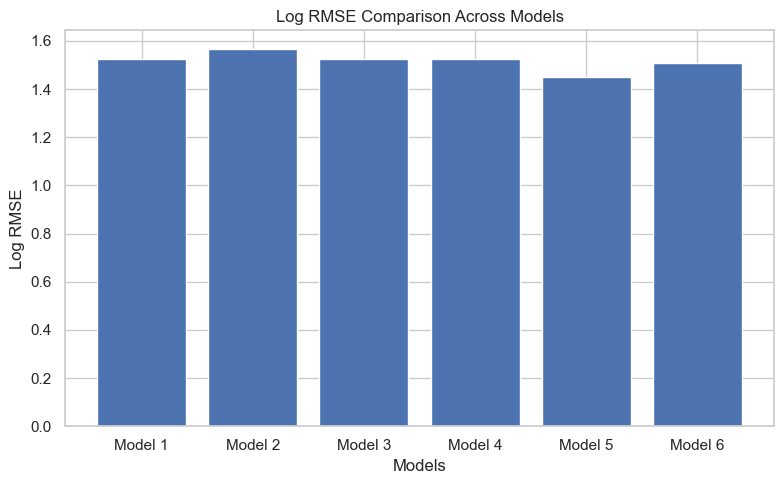

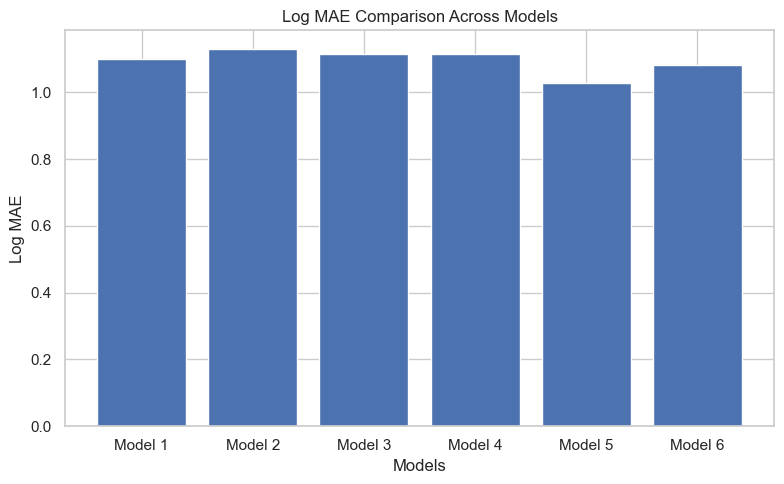

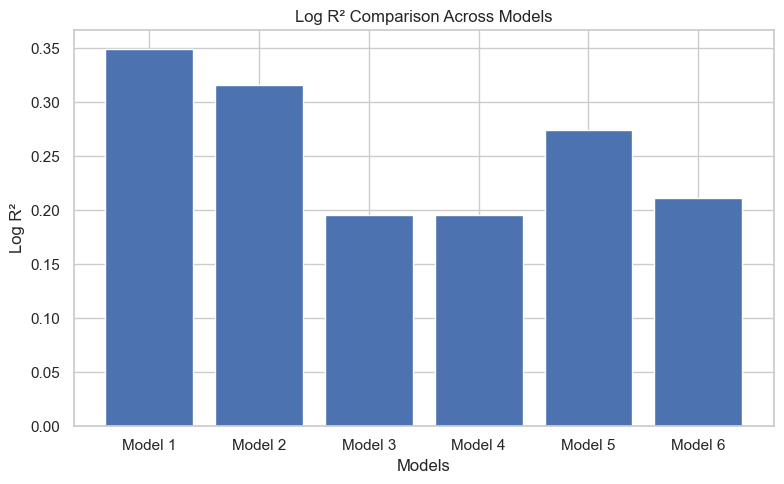

In [91]:

# Model versions
models = ["Model 1", "Model 2", "Model 3", "Model 4", "Model 5", "Model 6"]

# Log-scale metrics
rmse_log = [
    rmse_v1_log, rmse_v2_log, rmse_v3_log,
    rmse_v4_log, rmse_v5_log, rmse_v6_log
]

mae_log = [
    mae_v1_log, mae_v2_log, mae_v3_log,
    mae_v4_log, mae_v5_log, mae_v6_log
]

r2_log = [
    r2_v1_log, r2_v2_log, r2_v3_log,
    r2_v4_log, r2_v5_log, r2_v6_log
]

# --- RMSE (log) ---
plt.figure(figsize=(8, 5))
plt.bar(models, rmse_log)
plt.title("Log RMSE Comparison Across Models")
plt.xlabel("Models")
plt.ylabel("Log RMSE")
plt.tight_layout()
plt.show()

# --- MAE (log) ---
plt.figure(figsize=(8, 5))
plt.bar(models, mae_log)
plt.title("Log MAE Comparison Across Models")
plt.xlabel("Models")
plt.ylabel("Log MAE")
plt.tight_layout()
plt.show()

# --- R² (log) ---
plt.figure(figsize=(8, 5))
plt.bar(models, r2_log)
plt.title("Log R² Comparison Across Models")
plt.xlabel("Models")
plt.ylabel("Log R²")
plt.tight_layout()
plt.show()

While Model 1 achieved the highest R², Model 5 demonstrated superior performance in terms of RMSE and MAE, indicating more accurate predictions overall. Given the objective of minimizing prediction error, Model 5 was selected as the final model due to its balanced performance and lower overall error.